最常用的闵可夫斯基距离族：
    欧氏距离 (L2距离，最常用)
    曼哈顿距离 (L1距离)
    切比雪夫距离 (L∞距离)
    闵可夫斯基距离 (统一形式)

闵可夫斯基距离 (统一形式)
    余弦相似度 (距离 = 1 - 相似度)
    马氏距离（考虑特征相关性）



# 训练数据示例
训练样本1: [花萼长5.1, 花萼宽3.5, 花瓣长1.4, 花瓣宽0.2] → 类别: "山鸢尾"
训练样本2: [花萼长4.9, 花萼宽3.0, 花瓣长1.4, 花瓣宽0.2] → 类别: "山鸢尾"  
训练样本3: [花萼长6.5, 花萼宽3.0, 花瓣长5.2, 花瓣宽2.0] → 类别: "维吉尼亚鸢尾"

# 对新样本投票
新样本: [花萼长5.5, 花萼宽3.2, 花瓣长1.5, 花瓣宽0.3]

找到最近的3个邻居:
- 邻居1 (距离0.3) → 投 "山鸢尾" 一票
- 邻居2 (距离0.4) → 投 "山鸢尾" 一票
- 邻居3 (距离0.8) → 投 "维吉尼亚鸢尾" 一票

投票结果: 山鸢尾(2票) vs 维吉尼亚鸢尾(1票)
最终预测: 山鸢尾

**每个邻居的投票就是它的标签值**

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter

import platform

def set_chinese_font():
    system = platform.system()
    if system == 'Windows':
        plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
    elif system == 'Darwin':  # macOS
        plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS']
    else:  # Linux
        plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

set_chinese_font() 

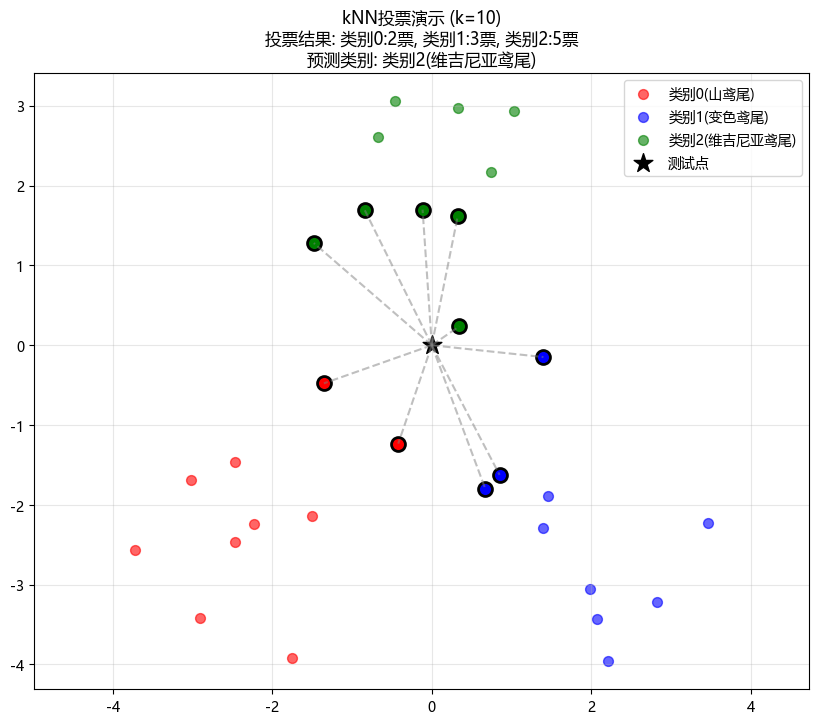

最近的10个邻居的标签: [2, 0, 1, 0, 2, 2, 1, 2, 1, 2]
投票统计: {np.int64(2): 5, np.int64(0): 2, np.int64(1): 3}


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 创建简单数据集
np.random.seed(42)
# 三个类别的数据
class0 = np.random.randn(10, 2) + [-2, -2]  # 类别0
class1 = np.random.randn(10, 2) + [2, -2]   # 类别1
class2 = np.random.randn(10, 2) + [0, 2]    # 类别2

X_train = np.vstack([class0, class1, class2])
y_train = np.array([0]*10 + [1]*10 + [2]*10)

# 测试点
test_point = np.array([0, 0])

# 计算距离
distances = [np.linalg.norm(test_point - x) for x in X_train]
k = 10
k_indices = np.argsort(distances)[:k]
k_labels = y_train[k_indices]

# 可视化
plt.figure(figsize=(10, 8))

# 画训练数据
colors = {0: 'red', 1: 'blue', 2: 'green'}
labels_name = {0: '类别0(山鸢尾)', 1: '类别1(变色鸢尾)', 2: '类别2(维吉尼亚鸢尾)'}

for label in [0, 1, 2]:
    mask = y_train == label
    plt.scatter(X_train[mask, 0], X_train[mask, 1], 
               c=colors[label], label=labels_name[label], 
               alpha=0.6, s=50)

# 画测试点
plt.scatter(test_point[0], test_point[1], 
           c='black', marker='*', s=200, label='测试点')

# 画最近的k个邻居
for idx in k_indices:
    plt.plot([test_point[0], X_train[idx, 0]], 
            [test_point[1], X_train[idx, 1]], 
            'gray', linestyle='--', alpha=0.5)
    plt.scatter(X_train[idx, 0], X_train[idx, 1],
               edgecolors='black', linewidth=2,
               facecolors=colors[y_train[idx]], s=100)

# 添加投票结果
vote_counts = Counter(k_labels)
plt.title(f'kNN投票演示 (k={k})\n投票结果: 类别0:{vote_counts[0]}票, '
          f'类别1:{vote_counts[1]}票, 类别2:{vote_counts[2]}票\n'
          f'预测类别: {labels_name[max(vote_counts, key=vote_counts.get)]}', 
          fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

print(f"最近的{k}个邻居的标签: {k_labels.tolist()}")
print(f"投票统计: {dict(vote_counts)}")

In [2]:
# 加载鸢尾花数据集
iris = load_iris()
X = iris.data  # 特征
y = iris.target  # 标签

# 查看数据基本信息
print("特征名称:", iris.feature_names)
print("类别名称:", iris.target_names)
print("样本数量:", len(X))
print("特征维度:", X.shape[1])

# 转换为DataFrame便于查看
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
print("\n前5行数据:")
print(df.head())

特征名称: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
类别名称: ['setosa' 'versicolor' 'virginica']
样本数量: 150
特征维度: 4

前5行数据:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [ ]:
class KNN:
    def __init__(self, k=3):
        """
        初始化kNN分类器
        k: 最近邻的数量
        """
        self.k = k
    
    def fit(self, X, y):
        """
        训练方法：实际上只是存储训练数据
        X: 训练特征
        y: 训练标签
        """
        self.X_train = X
        self.y_train = y
    
    def euclidean_distance(self, x1, x2):
        """计算欧氏距离"""
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def predict_single(self, x):
        """预测单个样本"""
        # 1. 计算与所有训练样本的距离
        distances = [self.euclidean_distance(x, x_train) 
                    for x_train in self.X_train]
        
        # 2. 获取k个最近邻的索引
        k_indices = np.argsort(distances)[:self.k]
        
        # 3. 获取这k个邻居的标签
        k_labels = [self.y_train[i] for i in k_indices]
        
        # 4. 投票(简单投票,加权投票,软投票)决定**预测标签**
        most_common = Counter(k_labels).most_common(1)
        return most_common[0][0]
    
    def predict(self, X):
        """预测多个样本"""
        predictions = [self.predict_single(x) for x in X]
        return np.array(predictions)
    
    def accuracy(self, X_test, y_test):
        """计算准确率"""
        predictions = self.predict(X_test)
        return np.mean(predictions == y_test)

In [4]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"训练集大小: {len(X_train)}")
print(f"测试集大小: {len(X_test)}")

# 特征标准化（重要！）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

训练集大小: 120
测试集大小: 30


In [ ]:
# 创建kNN模型
knn = KNN(k=3) # 最近的k个训练样本

# 训练
knn.fit(X_train_scaled, y_train)

# 预测
y_pred = knn.predict(X_test_scaled)

# 评估
accuracy = knn.accuracy(X_test_scaled, y_test)
print(f"模型准确率: {accuracy:.2f}")

# 显示详细预测结果
print("\n预测结果对比（前10个）:")
for i in range(10):
    print(f"真实: {iris.target_names[y_test[i]]}, "
          f"预测: {iris.target_names[y_pred[i]]}")

模型准确率: 1.00

预测结果对比（前10个）:
真实: setosa, 预测: setosa
真实: virginica, 预测: virginica
真实: versicolor, 预测: versicolor
真实: versicolor, 预测: versicolor
真实: setosa, 预测: setosa
真实: versicolor, 预测: versicolor
真实: setosa, 预测: setosa
真实: setosa, 预测: setosa
真实: virginica, 预测: virginica
真实: versicolor, 预测: versicolor


最优k值: 10
最优准确率: 1.00


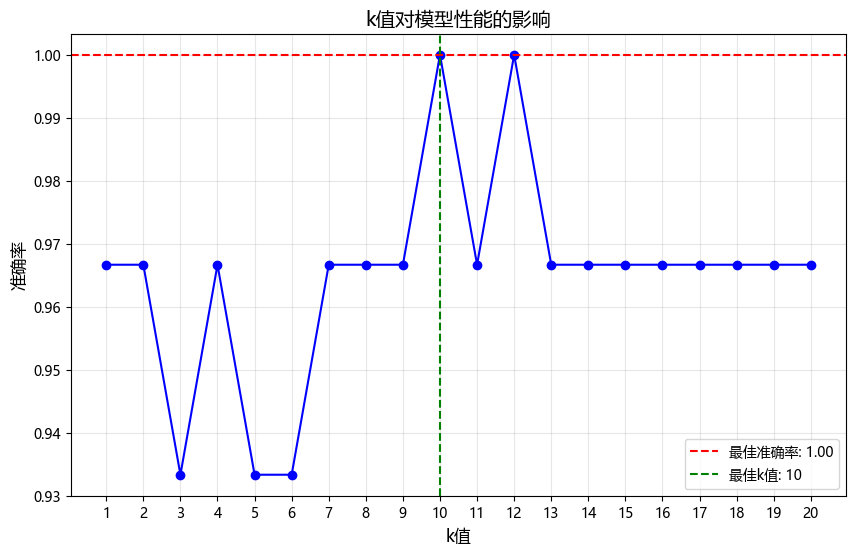

In [8]:
# 测试不同的k值
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train_scaled, y_train)
    acc = knn.accuracy(X_test_scaled, y_test)
    accuracies.append(acc)

# 可视化
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, 'bo-')
plt.xlabel('k值', fontsize=12)
plt.ylabel('准确率', fontsize=12)
plt.title('k值对模型性能的影响', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

# 找到最优k值
best_k = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f"最优k值: {best_k}")
print(f"最优准确率: {best_acc:.2f}")

plt.axhline(y=best_acc, color='r', linestyle='--', 
            label=f'最佳准确率: {best_acc:.2f}')
plt.axvline(x=best_k, color='g', linestyle='--', 
            label=f'最佳k值: {best_k}')
plt.legend()
plt.show()

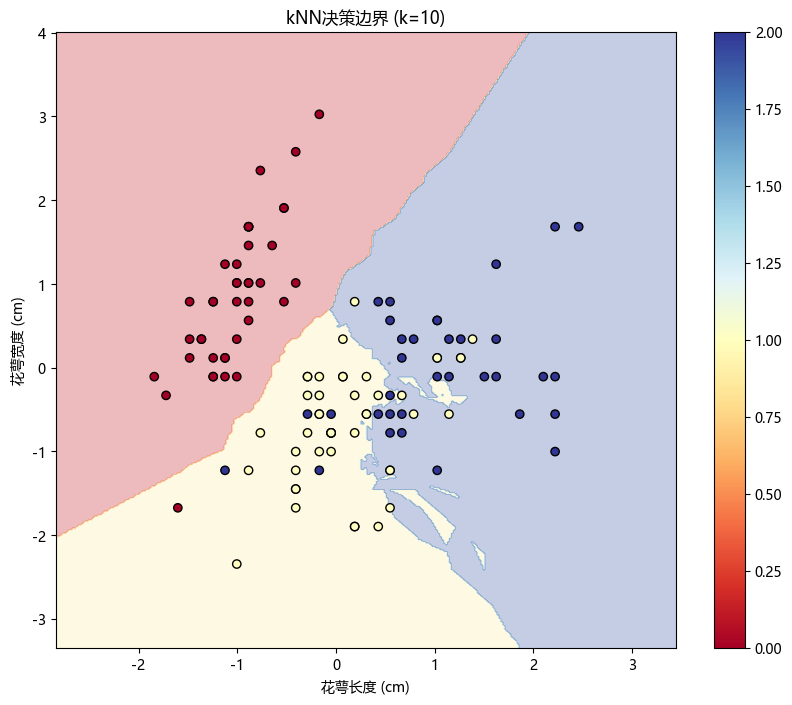

In [9]:
# 使用两个特征进行可视化（花萼长度和花萼宽度）
def plot_decision_boundary(X, y, k=3):
    # 只取前两个特征
    X_2d = X[:, :2]
    
    # 创建网格
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # 预测网格点的类别
    knn = KNN(k=k)
    knn.fit(X_2d, y)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 绘制
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, 
                          cmap=plt.cm.RdYlBu, edgecolor='black')
    plt.xlabel('花萼长度 (cm)')
    plt.ylabel('花萼宽度 (cm)')
    plt.title(f'kNN决策边界 (k={k})')
    plt.colorbar(scatter)
    plt.show()

# 绘制决策边界
plot_decision_boundary(X_train_scaled, y_train, k=best_k)

In [10]:
# 8. 使用sklearn实现（简洁版

from sklearn.neighbors import KNeighborsClassifier

# 使用sklearn的kNN
sklearn_knn = KNeighborsClassifier(n_neighbors=best_k)
sklearn_knn.fit(X_train_scaled, y_train)

# 评估
sklearn_accuracy = sklearn_knn.score(X_test_scaled, y_test)
print(f"sklearn kNN准确率: {sklearn_accuracy:.2f}")

# 预测新样本
new_samples = np.array([[5.0, 3.5, 1.5, 0.2],  # 类似山鸢尾
                        [6.5, 3.0, 5.5, 2.0]])  # 类似维吉尼亚鸢尾
new_samples_scaled = scaler.transform(new_samples)
predictions = sklearn_knn.predict(new_samples_scaled)

for i, pred in enumerate(predictions):
    print(f"样本{i+1}预测类别: {iris.target_names[pred]}")

sklearn kNN准确率: 0.97
样本1预测类别: setosa
样本2预测类别: virginica
